# ScientISST_MOVE

In [18]:
import scipy.signal as sg


# -----------------------------
# Filtering helpers
# -----------------------------
def butter_bandpass(lowcut, highcut, fs, order=20):
    nyq = 0.5 * fs
    b, a = sg.butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return b, a


def butter_lowpass(cutoff, fs, order=20):
    nyq = 0.5 * fs
    b, a = sg.butter(order, cutoff / nyq, btype='low')
    return b, a


def apply_filter(x, fs, mode="ecg"):
    if len(x) < 16:
        return x 
    if mode == "ecg":
         b, a = butter_bandpass(1, 40, fs, order=4)
         # b, a = butter_bandpass(39, 41, fs, order=20)
    elif mode == "ppg":
        b, a = butter_bandpass(0.5, 5, fs, order=4)
    elif mode == "eda":
        b, a = butter_lowpass(1, fs, order=4)
    elif mode == "acc":
        b, a = butter_lowpass(10, fs, order=4)
    else:
        return x
    return sg.filtfilt(b, a, x)


def resample_to(x, orig_fs, target_fs=100):
    if orig_fs == target_fs:
        return x
    n_samples = int(len(x) * target_fs / orig_fs)
    return sg.resample(x, n_samples)


def zscore(x):
    mean = np.mean(x)
    std = np.std(x)
    if std < 1e-8:
        return x - mean
    return (x - mean) / std


In [19]:
# =====================================
# File: load_optimized.py
# ScientISST MOVE — Optimized EDF multi-device loader
#   - Pre-processes and caches all windows during initialization
#   - Ensures slice-first, then filter/resample workflow
#   - Much faster __getitem__ access
# =====================================

from __future__ import annotations
import os
import re
import math
import logging
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
import pickle
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import Dataset
from torch.distributed import get_rank, is_initialized

try:
    import pyedflib
except Exception as e:
    raise ImportError("This loader requires 'pyEDFlib'. Install via: pip install pyEDFlib")

# from utils.filters import apply_filter, resample_to, zscore


# 配置日志
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

def log_info(msg):
    if not is_initialized() or get_rank() == 0:
        logger.info(msg)

# -----------------------------
# EDF helpers (unchanged)
# -----------------------------

@dataclass
class EDFSignal:
    label: str
    fs: float
    data: np.ndarray  # shape [T]


@dataclass
class EDFDevice:
    path: str
    start_time_epoch: float
    duration_sec: float
    signals: Dict[str, EDFSignal]
    annotations: List[Tuple[float, float, str]]  # (onset_sec, duration_sec, label)


def _read_edf_signals(path: str) -> EDFDevice:
    f = pyedflib.EdfReader(path)
    try:
        n_signals = f.signals_in_file
        labels = [f.getLabel(i).strip() for i in range(n_signals)]
        fs = [f.getSampleFrequency(i) for i in range(n_signals)]
        sigs = {}
        for i, lab in enumerate(labels):
            data = f.readSignal(i)
            sigs[lab] = EDFSignal(label=lab, fs=float(fs[i]), data=data.astype(np.float32))
        dt = f.getStartdatetime()
        start_epoch = dt.timestamp() if hasattr(dt, 'timestamp') else 0.0
        file_dur = float(f.getFileDuration())
        try:
            anns = f.readAnnotations()
            onsets = anns[0]
            durations = anns[1]
            ann_labels = [a.decode('utf-8') if isinstance(a, (bytes, bytearray)) else str(a) for a in anns[2]]
            annotations = [(float(o), float(d), s) for o, d, s in zip(onsets, durations, ann_labels)]
        except Exception:
            annotations = []
    finally:
        f.close()
    return EDFDevice(path=path, start_time_epoch=start_epoch, duration_sec=file_dur, signals=sigs,
                     annotations=annotations)


# -----------------------------
# Channel selection rules (unchanged)
# -----------------------------

DEFAULT_CHANNEL_PATTERNS = {
    'ecg': [r'ECG'],
    'ppg': [r'PPG', r'BVP'],
    'eda': [r'EDA', r'GSR'],
    'emg': [r'EMG'],
    'temp': [r'temp', r'Temperature'],
    'c_acc': [r'CHEST.*ACC.*X', r'CHEST.*ACC.*Y', r'CHEST.*ACC.*Z'],
    'w_acc': [r'WRIST.*ACC.*X', r'WRIST.*ACC.*Y', r'WRIST.*ACC.*Z'],
}

EMPATICA_HINTS = {
    'ppg': [r'BVP', r'PPG'],
    'eda': [r'EDA'],
    'temp': [r'TEMP', r'Temperature'],
    'w_acc': [r'ACC.*X', r'ACC.*Y', r'ACC.*Z'],
}
SCIENTISST_CHEST_HINTS = {
    'ecg_gel': [r'ECG.*gel'],       # 匹配 gel 电极
    'ecg_textile': [r'ECG.*dry'],
    'c_acc': [r'ACC.*X', r'ACC.*Y', r'ACC.*Z'],
}
SCIENTISST_FOREARM_HINTS = {
    'emg': [r'EMG'],
    'eda': [r'EDA'],  # S3
    'ppg': [r'PPG'],  # S5
}


def _match_first(label_list: List[str], patterns: List[str]) -> Optional[str]:
    for pat in patterns:
        regex = re.compile(pat, re.IGNORECASE)
        for lab in label_list:
            if regex.search(lab):
                return lab
    return None


# -----------------------------
# Pre-processed Window Data
# -----------------------------

@dataclass
class ProcessedWindow:
    """Stores pre-processed window data as integrated tensor"""
    subject_id: str
    window_idx: int
    x_tensor: torch.Tensor  # Integrated tensor [C=14, T]
    y: Optional[int]

    def __getstate__(self):
        # Convert tensor to numpy for pickling
        state = self.__dict__.copy()
        state['x_tensor'] = self.x_tensor.numpy()
        return state

    def __setstate__(self, state):
        # Convert numpy back to tensor
        self.__dict__.update(state)
        self.x_tensor = torch.from_numpy(self.x_tensor)


# -----------------------------
# Optimized Dataset
# -----------------------------

class MoveEDFWindowDataset(Dataset):
    def __init__(
            self,
            root: str,
            window_sec: float = 1.0,
            stride_sec: Optional[float] = 0.5,
            label_map: Optional[Dict[str, int]] = None,
            min_coverage: float = 0.95,
            channel_patterns: Optional[Dict[str, List[str]]] = None,
            none_policy: str = "extra_class",  # "ignore" | "extra_class"
            ignore_index: int = -100,
            cache_dir: Optional[str] = None,  # Directory to cache processed windows
            force_reprocess: bool = False,  # Force reprocessing even if cache exists
            norm_mode: Optional[str] = 'dataset',  # "dataset" for dataset-level normalization, None for no normalization
    ):
        super().__init__()
        self.root = root
        self.window_sec = float(window_sec)
        self.stride_sec = float(stride_sec) if stride_sec is not None else float(window_sec)
        self.min_coverage = float(min_coverage)
        self.patterns = channel_patterns or DEFAULT_CHANNEL_PATTERNS
        self.none_policy = none_policy
        self.ignore_index = ignore_index
        self.norm_mode = norm_mode

        # Setup cache
        self.cache_dir = cache_dir or os.path.join(root, '.cache')
        Path(self.cache_dir).mkdir(parents=True, exist_ok=True)
        cache_key = f"w{window_sec}_s{stride_sec}_c{min_coverage}_{none_policy}_{norm_mode}"
        self.cache_file = os.path.join(self.cache_dir, f"processed_windows_{cache_key}.pkl")

        log_info(f"Initializing dataset from {root}")
        log_info(f"Cache file: {self.cache_file}")

        # Try to load from cache first
        if not force_reprocess and os.path.exists(self.cache_file):
            log_info("Loading from cache...")
            try:
                with open(self.cache_file, 'rb') as f:
                    cache_data = pickle.load(f)
                    self.subjects = cache_data['subjects']
                    self.label_map = cache_data['label_map']
                    self.processed_windows = cache_data['processed_windows']
                    self.subject_to_windows = cache_data['subject_to_windows']
                    if norm_mode == 'dataset':
                        self.channel_mean = cache_data['channel_mean']
                        self.channel_std = cache_data['channel_std']
                    log_info(f"Loaded {len(self.processed_windows)} windows from cache")
                    return
            except Exception as e:
                log_info(f"Cache loading failed: {e}, reprocessing...")

        # Scan subjects
        log_info("Scanning subjects...")
        subs = []
        for sid in sorted(os.listdir(root)):
            subj_dir = os.path.join(root, sid)
            if not os.path.isdir(subj_dir):
                continue
            if all(os.path.exists(os.path.join(subj_dir, f)) for f in [
                'empatica.edf', 'scientisst_chest.edf', 'scientisst_forearm.edf'
            ]):
                subs.append(sid)
        if not subs:
            raise FileNotFoundError(f"No subjects found under {root}.")
        self.subjects = subs
        log_info(f"Found {len(subs)} subjects")

        # Read devices and collect labels
        log_info("Reading EDF files...")
        self.devices: Dict[str, Tuple[EDFDevice, EDFDevice, EDFDevice]] = {}
        all_label_strings: List[str] = []
        for i, sid in enumerate(self.subjects):
            if i % 5 == 0:
                log_info(f"Processing subject {i + 1}/{len(self.subjects)}: {sid}")
            sdir = os.path.join(root, sid)
            wrist = _read_edf_signals(os.path.join(sdir, 'empatica.edf'))
            chest = _read_edf_signals(os.path.join(sdir, 'scientisst_chest.edf'))
            fore = _read_edf_signals(os.path.join(sdir, 'scientisst_forearm.edf'))
            self.devices[sid] = (chest, fore, wrist)
            for dev in (chest, fore, wrist):
                for (_, _, lab) in dev.annotations:
                    all_label_strings.append(lab)

        # Setup label mapping
        if label_map is None:
            uniq = sorted(set(self._normalize_label(s) for s in all_label_strings))
            self.label_map = {s: i for i, s in enumerate(uniq)}
        else:
            self.label_map = label_map

        if self.none_policy == "extra_class" and "__none__" not in self.label_map:
            self.label_map["__none__"] = len(self.label_map)

        log_info(f"Label mapping: {self.label_map}")

        # Pre-process all windows
        log_info("Pre-processing all windows...")
        self._preprocess_all_windows()

        # Compute channel-wise statistics for normalization if needed
        if self.norm_mode == 'dataset':
            log_info("Computing channel-wise mean and std...")
            self.channel_mean, self.channel_std = self._compute_channel_stats()
            log_info(f"CHANNEL_MEAN shape: {self.channel_mean.shape}")
            log_info(f"CHANNEL_STD shape: {self.channel_std.shape}")
            
            # Apply normalization to all processed windows
            log_info("Applying dataset-level normalization...")
            self._apply_normalization()

        # Save to cache
        log_info("Saving to cache...")
        try:
            cache_data = {
                'subjects': self.subjects,
                'label_map': self.label_map,
                'processed_windows': self.processed_windows,
                'subject_to_windows': self.subject_to_windows,
            }
            if self.norm_mode == 'dataset':
                cache_data['channel_mean'] = self.channel_mean
                cache_data['channel_std'] = self.channel_std
            
            with open(self.cache_file, 'wb') as f:
                pickle.dump(cache_data, f)
            log_info(f"Cache saved to {self.cache_file}")
        except Exception as e:
            log_info(f"Cache saving failed: {e}")

    def _normalize_label(self, lab: str) -> str:
        # "lift-1", "lift-2" → "lift"
        if lab.startswith("lift"):
            return "lift"
        # " walk_before", "walk_before_downstairs", etc. → "walk_before"
        if lab.startswith("walk_before"):
            return "walk_before"
        return lab

    def _majority_label(self, devices: Tuple[EDFDevice, EDFDevice, EDFDevice], t0: float, dur: float) -> Optional[int]:
        votes: Dict[str, float] = {}
        for dev in devices:
            for onset, length, lab in dev.annotations:
                abs_onset = dev.start_time_epoch + float(onset)
                abs_end = abs_onset + float(length if length > 0 else 0.0)
                w0, w1 = t0, t0 + dur
                inter = max(0.0, min(abs_end, w1) - max(abs_onset, w0))
                if inter > 0:
                    norm_lab = self._normalize_label(lab)
                    votes[norm_lab] = votes.get(norm_lab, 0.0) + inter
        if not votes:
            return None
        lab = max(votes.items(), key=lambda kv: kv[1])[0]
        return self.label_map.get(lab, None)

    def _slice_and_process_signal(self, dev: EDFDevice, signal_key: str, t0_abs: float, dur: float,
                                  target_fs: float = 100, signal_type: str = "default") -> np.ndarray:
        """Slice signal from device, then apply filtering and resampling"""
        if signal_key not in dev.signals:
            # Return zeros if signal not found
            length = int(round(dur * target_fs))
            return np.zeros((length,), dtype=np.float32)

        sig = dev.signals[signal_key]
        fs = sig.fs

        # Step 1: Slice the signal
        rel_start = max(0.0, t0_abs - dev.start_time_epoch)
        i0 = int(round(rel_start * fs))
        i1 = int(round((rel_start + dur) * fs))
        x = sig.data[i0:i1]

        # Pad if needed
        expected_len = int(round(dur * fs))
        if x.shape[0] < expected_len:
            x = np.pad(x, (0, expected_len - x.shape[0]), mode='constant')

        # Step 2: Apply filtering (after slicing)
        if signal_type == "ecg":
            x = apply_filter(x, fs, "ecg")
        elif signal_type == "ppg":
            x = apply_filter(x, fs, "ppg")
        elif signal_type == "eda":
            x = apply_filter(x, fs, "eda")
        elif signal_type == "acc":
            x = apply_filter(x, fs, "acc")

        # Step 3: Resample to target frequency
        x = resample_to(x, fs, target_fs)

        return x.astype(np.float32)

    def _integrate_signals_to_tensor(self, wrist_signals: dict, chest_signals: dict, fore_signals: dict) -> torch.Tensor:
        """Integrate all signals into a single tensor [C=14, T]"""
        # Single-channel signals (8 channels)
        parts = []
        
        # Add single-channel signals in order
        signal_keys = [
            ('ecg_chest_gel', chest_signals.get('ecg_gel', np.zeros(100))),
            ('ecg_chest_textile', chest_signals.get('ecg_textile', np.zeros(100))),
            ('eda_forearm_scientisst', fore_signals.get('eda', np.zeros(100))),
            ('eda_wrist_e4', wrist_signals.get('eda', np.zeros(100))),
            ('ppg_forearm_scientisst', fore_signals.get('ppg', np.zeros(100))),
            ('ppg_wrist_e4', wrist_signals.get('ppg', np.zeros(100))),
            ('emg_forearm', fore_signals.get('emg', np.zeros(100))),
            ('temp_wrist', wrist_signals.get('temp', np.zeros(100))),
        ]
        
        for _, signal in signal_keys:
            # Ensure signal is 1D, then convert to tensor and add channel dim
            if signal.ndim == 1:
                parts.append(torch.from_numpy(signal).unsqueeze(0))  # [1, T]
            else:
                parts.append(torch.from_numpy(signal))  # Should already be [1, T]
        
        # Multi-channel accelerometer signals (6 channels total)
        c_acc = chest_signals.get('c_acc', np.zeros((3, 100)))  # [3, 100]
        w_acc = wrist_signals.get('w_acc', np.zeros((3, 100)))   # [3, 100]
        
        # Convert to tensors
        c_acc_tensor = torch.from_numpy(c_acc)  # [3, T]
        w_acc_tensor = torch.from_numpy(w_acc)  # [3, T]
        
        # Ensure correct dimensions
        if c_acc_tensor.dim() == 1:
            c_acc_tensor = c_acc_tensor.unsqueeze(0)  # [1, T] -> will be split later
        if w_acc_tensor.dim() == 1:
            w_acc_tensor = w_acc_tensor.unsqueeze(0)  # [1, T] -> will be split later
            
        # Split accelerometer channels and add to parts
        c_chs = list(torch.unbind(c_acc_tensor, dim=0))  # List of [T] tensors
        c_chs = [ch.unsqueeze(0) if ch.dim() == 1 else ch for ch in c_chs]  # Ensure [1, T]
        
        w_chs = list(torch.unbind(w_acc_tensor, dim=0))  # List of [T] tensors  
        w_chs = [ch.unsqueeze(0) if ch.dim() == 1 else ch for ch in w_chs]  # Ensure [1, T]
        
        # Concatenate all parts: 8 single + 3 chest_acc + 3 wrist_acc = 14 channels
        all_parts = parts + c_chs + w_chs
        x_integrated = torch.cat(all_parts, dim=0)  # [14, T]
        
        return x_integrated

    def _preprocess_single_window(self, subject_id: str, t0: float, dur: float) -> ProcessedWindow:
        """Process a single window and return ProcessedWindow object with integrated tensor"""
        chest, fore, wrist = self.devices[subject_id]

        # Get label for this window
        y = self._majority_label((chest, fore, wrist), t0, dur)
        if y is None:
            if self.none_policy == "ignore":
                y = self.ignore_index
            elif self.none_policy == "extra_class":
                y = self.label_map["__none__"]

        # Process wrist signals
        wrist_signals = {}
        for key, patterns in EMPATICA_HINTS.items():
            matched_label = _match_first(list(wrist.signals.keys()), patterns)
            if matched_label:
                if key == 'ppg':
                    wrist_signals[key] = self._slice_and_process_signal(wrist, matched_label, t0, dur, 100, "ppg")
                elif key == 'eda':
                    wrist_signals[key] = self._slice_and_process_signal(wrist, matched_label, t0, dur, 100, "eda")
                elif key == 'temp':
                    wrist_signals[key] = self._slice_and_process_signal(wrist, matched_label, t0, dur, 100, "default")
                elif key == 'w_acc':
                    # Handle 3-axis accelerometer
                    acc_labels = [_match_first(list(wrist.signals.keys()), [p]) for p in patterns]
                    acc_data = []
                    for acc_label in acc_labels:
                        if acc_label:
                            acc_data.append(self._slice_and_process_signal(wrist, acc_label, t0, dur, 100, "acc"))
                        else:
                            acc_data.append(np.zeros(100, dtype=np.float32))
                    wrist_signals['w_acc'] = np.stack(acc_data, axis=0)  # [3, 100]
            else:
                if key == 'w_acc':
                    wrist_signals[key] = np.zeros((3, 100), dtype=np.float32)
                else:
                    wrist_signals[key] = np.zeros(100, dtype=np.float32)

        # Process chest signals
        chest_signals = {}
        for key, patterns in SCIENTISST_CHEST_HINTS.items():
            matched_label = _match_first(list(chest.signals.keys()), patterns)
            if matched_label:
                if key in ['ecg_gel', 'ecg_textile']:
                    chest_signals[key] = self._slice_and_process_signal(chest, matched_label, t0, dur, 100, "ecg")
                elif key == 'c_acc':
                    # Handle 3-axis accelerometer
                    acc_labels = [_match_first(list(chest.signals.keys()), [p]) for p in patterns]
                    acc_data = []
                    for acc_label in acc_labels:
                        if acc_label:
                            acc_data.append(self._slice_and_process_signal(chest, acc_label, t0, dur, 100, "acc"))
                        else:
                            acc_data.append(np.zeros(100, dtype=np.float32))
                    chest_signals['c_acc'] = np.stack(acc_data, axis=0)  # [3, 100]
            else:
                if key == 'c_acc':
                    chest_signals[key] = np.zeros((3, 100), dtype=np.float32)
                else:
                    chest_signals[key] = np.zeros(100, dtype=np.float32)

        # Process forearm signals
        fore_signals = {}
        for key, patterns in SCIENTISST_FOREARM_HINTS.items():
            matched_label = _match_first(list(fore.signals.keys()), patterns)
            if matched_label:
                if key == 'emg':
                    fore_signals[key] = self._slice_and_process_signal(fore, matched_label, t0, dur, 100, "default")
                elif key == 'eda':
                    fore_signals[key] = self._slice_and_process_signal(fore, matched_label, t0, dur, 100, "eda")
                elif key == 'ppg':
                    fore_signals[key] = self._slice_and_process_signal(fore, matched_label, t0, dur, 100, "ppg")
            else:
                fore_signals[key] = np.zeros(100, dtype=np.float32)

        # Integrate all signals into single tensor
        x_tensor = self._integrate_signals_to_tensor(wrist_signals, chest_signals, fore_signals)

        return ProcessedWindow(
            subject_id=subject_id,
            window_idx=-1,  # Will be set later
            x_tensor=x_tensor,  # [14, 100]
            y=y
        )

    def _preprocess_all_windows(self):
        """Pre-process all windows for all subjects"""
        self.processed_windows: List[ProcessedWindow] = []
        self.subject_to_windows: Dict[str, List[int]] = {}  # subject_id -> list of window indices

        total_windows = 0
        for sid in self.subjects:
            chest, fore, wrist = self.devices[sid]
            start_max = max(chest.start_time_epoch, fore.start_time_epoch, wrist.start_time_epoch)
            end_min = min(
                chest.start_time_epoch + chest.duration_sec,
                fore.start_time_epoch + fore.duration_sec,
                wrist.start_time_epoch + wrist.duration_sec,
            )
            total_duration = max(0.0, end_min - start_max)
            if total_duration < self.window_sec * self.min_coverage:
                continue
            n_windows = int(math.floor((total_duration - self.window_sec) / self.stride_sec) + 1)
            total_windows += n_windows

        log_info(f"Total windows to process: {total_windows}")

        processed_count = 0
        for sid in self.subjects:
            log_info(f"Processing subject {sid}...")
            chest, fore, wrist = self.devices[sid]
            start_max = max(chest.start_time_epoch, fore.start_time_epoch, wrist.start_time_epoch)
            end_min = min(
                chest.start_time_epoch + chest.duration_sec,
                fore.start_time_epoch + fore.duration_sec,
                wrist.start_time_epoch + wrist.duration_sec,
            )
            total_duration = max(0.0, end_min - start_max)
            if total_duration < self.window_sec * self.min_coverage:
                continue

            n_windows = int(math.floor((total_duration - self.window_sec) / self.stride_sec) + 1)
            subject_window_indices = []

            for i in range(n_windows):
                t0 = start_max + i * self.stride_sec
                processed_window = self._preprocess_single_window(sid, t0, self.window_sec)
                processed_window.window_idx = len(self.processed_windows)

                self.processed_windows.append(processed_window)
                subject_window_indices.append(processed_window.window_idx)

                processed_count += 1
                if processed_count % 10000 == 0:
                    log_info(f"Processed {processed_count}/{total_windows} windows")

            self.subject_to_windows[sid] = subject_window_indices

        log_info(f"Pre-processing complete! Total windows: {len(self.processed_windows)}")

    def _compute_channel_stats(self) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Compute per-channel mean and std across all windows
        Returns:
            channel_mean: torch.Tensor of shape [C] 
            channel_std: torch.Tensor of shape [C]
        """
        if not self.processed_windows:
            raise ValueError("No processed windows available for computing statistics")

        # Get first window to determine shape
        first_tensor = self.processed_windows[0].x_tensor  # [C, T]
        C, T = first_tensor.shape
        
        # Accumulate statistics
        sum_vals = torch.zeros(C, dtype=torch.float64)
        sum_squares = torch.zeros(C, dtype=torch.float64)
        count = 0

        for window in self.processed_windows:
            tensor = window.x_tensor.float()  # [C, T]
            # Compute mean and variance per channel
            channel_means = tensor.mean(dim=1)  # [C]
            channel_vars = tensor.var(dim=1, unbiased=False)  # [C]
            
            sum_vals += channel_means.double()
            sum_squares += (channel_vars + channel_means.pow(2)).double()
            count += 1

        # Compute final statistics
        channel_mean = (sum_vals / count).float()
        channel_std = torch.sqrt(sum_squares / count - channel_mean.pow(2).double()).float()
        
        # Clamp std to avoid division by zero
        channel_std = channel_std.clamp(min=1e-6)

        return channel_mean, channel_std

    def _apply_normalization(self):
        """Apply dataset-level normalization to all processed windows"""
        if not hasattr(self, 'channel_mean') or not hasattr(self, 'channel_std'):
            raise ValueError("Channel statistics not computed")
            
        log_info("Applying normalization to all windows...")
        
        # Expand dimensions for broadcasting: [C] -> [C, 1]
        mean = self.channel_mean.view(-1, 1)  # [C, 1]
        std = self.channel_std.view(-1, 1)    # [C, 1]
        
        for i, window in enumerate(self.processed_windows):
            # Apply normalization: (x - mean) / std
            window.x_tensor = (window.x_tensor.float() - mean) / std
            
            if i % 10000 == 0:
                log_info(f"Normalized {i}/{len(self.processed_windows)} windows")

    def __len__(self):
        return len(self.processed_windows)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        """Fast access to pre-processed and integrated data"""
        window = self.processed_windows[idx]
        y = -1 if window.y is None else int(window.y)
        return window.x_tensor, y  # [C=14, T], int

    def get_subject_sequence(self, subject_id: str) -> List[Tuple[torch.Tensor, int]]:
        """Get all windows for a specific subject as a sequence"""
        if subject_id not in self.subject_to_windows:
            return []

        sequence = []
        for window_idx in self.subject_to_windows[subject_id]:
            window = self.processed_windows[window_idx]
            y = -1 if window.y is None else int(window.y)
            sequence.append((window.x_tensor, y))

        return sequence



# -----------------------------
# Utility functions (unchanged)
# -----------------------------

def split_by_subject(dataset: MoveEDFWindowDataset, val_ratio: float = 0.2):
    rng = np.random.default_rng(42)
    sub_ids = dataset.subjects
    n_val = max(1, int(round(len(sub_ids) * val_ratio)))
    val_subs = set(rng.choice(sub_ids, size=n_val, replace=False).tolist())

    train_idx, val_idx = [], []
    for i, window in enumerate(dataset.processed_windows):
        if window.subject_id in val_subs:
            val_idx.append(i)
        else:
            train_idx.append(i)

    return train_idx, val_idx


def filter_labels(dataset: MoveEDFWindowDataset, remove_labels):
    """移除指定标签并更新数据集"""
    remove_set = set(remove_labels)
    to_remove = [lbl for lbl in dataset.label_map if lbl in remove_set]

    if not to_remove:
        return dataset

    # 找到要移除的标签ID
    remove_ids = {dataset.label_map[lbl] for lbl in to_remove}

    # 重建标签映射
    new_label_map = {}
    new_id = 0
    id_map = {}
    for lbl, old_id in dataset.label_map.items():
        if lbl in remove_set:
            continue
        new_label_map[lbl] = new_id
        id_map[old_id] = new_id
        new_id += 1

    # 更新数据集
    dataset.label_map = new_label_map

    # 过滤处理后的窗口
    filtered_windows = []
    new_subject_to_windows = {}

    for window in dataset.processed_windows:
        # 跳过要移除标签的窗口
        if window.y is not None and window.y in remove_ids:
            continue
        
        # 处理特殊标签值
        if window.y is None or window.y == dataset.ignore_index:
            # 保持None和ignore_index不变
            pass
        else:
            # 更新正常的标签ID
            window.y = id_map[window.y]
        
        window.window_idx = len(filtered_windows)
        filtered_windows.append(window)

        # 更新受试者映射
        if window.subject_id not in new_subject_to_windows:
            new_subject_to_windows[window.subject_id] = []
        new_subject_to_windows[window.subject_id].append(window.window_idx)

    dataset.processed_windows = filtered_windows
    dataset.subject_to_windows = new_subject_to_windows

    return dataset

In [20]:
data_root='/Users/chengweizhou/PycharmProjects/data/scientisst-move-annotated-wearable-multimodal-biosignals-recorded-during-everyday-life-activities-in-naturalistic-environments-1.0.1'

dataset = MoveEDFWindowDataset(root=data_root, window_sec=1, stride_sec=10, none_policy= "ignore_index", force_reprocess=True)
dataset = filter_labels(dataset, remove_labels=["sprint"])

print(dataset.subjects)
# dataset.index_per_subject['03FH']
seq = dataset.get_subject_sequence('LK27')
print(dataset.label_map)



INFO:__main__:Initializing dataset from /Users/chengweizhou/PycharmProjects/data/scientisst-move-annotated-wearable-multimodal-biosignals-recorded-during-everyday-life-activities-in-naturalistic-environments-1.0.1
INFO:__main__:Cache file: /Users/chengweizhou/PycharmProjects/data/scientisst-move-annotated-wearable-multimodal-biosignals-recorded-during-everyday-life-activities-in-naturalistic-environments-1.0.1/.cache/processed_windows_w1_s10_c0.95_ignore_index_dataset.pkl
INFO:__main__:Scanning subjects...
INFO:__main__:Found 15 subjects
INFO:__main__:Reading EDF files...
INFO:__main__:Processing subject 1/15: 03FH
INFO:__main__:Processing subject 6/15: AP3H
INFO:__main__:Processing subject 11/15: KF93
INFO:__main__:Label mapping: {'baseline': 0, 'gesticulate': 1, 'greetings': 2, 'jumps': 3, 'lift': 4, 'run': 5, 'sprint': 6, 'walk_after': 7, 'walk_before': 8}
INFO:__main__:Pre-processing all windows...
INFO:__main__:Total windows to process: 4487
INFO:__main__:Processing subject 03FH..

['03FH', '3B8D', '3RFH', '4JF9', '93DK', 'AP3H', 'F408', 'H39D', 'JD3K', 'K2Q2', 'KF93', 'KS03', 'LAS2', 'LDM5', 'LK27']
{'baseline': 0, 'gesticulate': 1, 'greetings': 2, 'jumps': 3, 'lift': 4, 'run': 5, 'walk_after': 6, 'walk_before': 7}


In [52]:
dataset = filter_labels(dataset, remove_labels=["sprint"])

In [45]:
print(seq[150][1]) 
print(dataset.channel_mean)
print(dataset.channel_std)

5
tensor([ 4.3659e-04,  5.7421e-04,  1.2727e+01,  2.7972e+01,  1.1085e-04,
        -8.8788e-04,  1.1071e+00,  3.2994e+01, -4.8464e-01, -4.7107e-01,
        -3.2242e-01, -7.0274e-01,  3.6353e-01, -1.3623e-02])
tensor([ 0.4479,  0.4756,  8.8863, 32.4762,  0.2736,  0.9708,  0.8150,  2.3742,
         0.3823,  0.3897,  0.4263,  0.7440,  0.7700,  0.4592])


In [24]:
print(seq[10][0][0])
print(seq[10][0][1])
print(seq[20][0][2])
print(dataset.devices['LK27'][2].signals.keys())

tensor([ 0.0306, -0.0370, -0.0294, -0.0740, -0.1214, -0.1407, -0.1185, -0.1733,
        -0.2386, -0.2621, -0.2916, -0.3343, -0.3641, -0.4100, -0.4401, -0.4784,
        -0.4706, -0.4072, -0.2993, -0.1552, -0.0172,  0.0779,  0.1210,  0.1497,
         0.1611,  0.1626,  0.1468,  0.1174,  0.1369,  0.1150,  0.0831,  0.0833,
         0.0851,  0.1263,  0.1374,  0.1180,  0.1201,  0.1290,  0.1309,  0.0957,
         0.0610,  0.0850,  0.1322,  0.1572,  0.1387,  0.1428,  0.1549,  0.1603,
         0.1660,  0.1248,  0.0732,  0.0860,  0.1144,  0.1482,  0.1567,  0.1708,
         0.1694,  0.1486,  0.1067,  0.0762, -0.1406, -1.5494, -2.5632, -0.1744,
         1.5146,  0.5300,  0.1158,  0.2657,  0.2216,  0.1852,  0.1595,  0.1480,
         0.1537,  0.1349,  0.1169,  0.0955,  0.0929,  0.0829,  0.0518,  0.0292,
        -0.0234, -0.0665, -0.1141, -0.1695, -0.2097, -0.2660, -0.3265, -0.3710,
        -0.4026, -0.3750, -0.3265, -0.1801,  0.0115,  0.1291,  0.1767,  0.1871,
         0.1571,  0.1634,  0.1432,  0.11

## Timestap Check

In [6]:
data_root='/Users/chengweizhou/PycharmProjects/data/scientisst-move-annotated-wearable-multimodal-biosignals-recorded-during-everyday-life-activities-in-naturalistic-environments-1.0.1'

In [7]:
# p = '03FH'
# p = '3B8D'
# p = 'JD3K'
p = 'LK27'
f1 = pyedflib.EdfReader(os.path.join(os.path.join(data_root, p), 'scientisst_chest.edf'))
f2 = pyedflib.EdfReader(os.path.join(os.path.join(data_root, p), 'scientisst_forearm.edf'))
f3 = pyedflib.EdfReader(os.path.join(os.path.join(data_root, p), 'empatica.edf'))
# methods = dir(f1)

In [8]:
n_signals = f1.signals_in_file
fs1 = [f1.getSampleFrequency(i) for i in range(n_signals)]
print(fs1)
labels = [f1.getLabel(i).strip() for i in range(n_signals)]
print(labels)

n_signals = f2.signals_in_file
fs2 = [f2.getSampleFrequency(i) for i in range(n_signals)]
print(fs2)
labels = [f2.getLabel(i).strip() for i in range(n_signals)]
print(labels)

n_signals = f3.signals_in_file
fs3 = [f3.getSampleFrequency(i) for i in range(n_signals)]
print(fs3)
labels = [f3.getLabel(i).strip() for i in range(n_signals)]
print(labels)

[500.0, 500.0, 500.0, 500.0, 500.0]
['ecg:dry', 'ecg:gel', 'acc_chest:x', 'acc_chest:y', 'acc_chest:z']
[500.0, 500.0, 500.0]
['eda:gel', 'ppg:finger', 'emg']
[4.0, 32.0, 32.0, 32.0, 64.0, 4.0]
['eda:dry', 'acc_e4:z', 'acc_e4:x', 'acc_e4:y', 'ppg:wrist', 'temp']


In [9]:
dt1 = f1.getStartdatetime()
print(dt1.timestamp())
print(float(f1.getFileDuration()))

dt2 = f2.getStartdatetime()
print(dt2.timestamp())
print(float(f2.getFileDuration()))

dt3 = f3.getStartdatetime()
print(dt3.timestamp())
print(float(f3.getFileDuration()))

946702878.0
3709.0
946702878.0
3709.0
946702800.0
3900.0


In [10]:
anns=f1.readAnnotations()
print(anns)
onsets = anns[0]
durations = anns[1]
ann_labels = [a.decode('utf-8') if isinstance(a, (bytes, bytearray)) else str(a) for a in anns[2]]
annotations = [(float(o), float(d), s) for o, d, s in zip(onsets, durations, ann_labels)]
print(ann_labels)
print(annotations)
print('\n')

anns=f2.readAnnotations()
print(anns)
onsets = anns[0]
durations = anns[1]
ann_labels = [a.decode('utf-8') if isinstance(a, (bytes, bytearray)) else str(a) for a in anns[2]]
annotations = [(float(o), float(d), s) for o, d, s in zip(onsets, durations, ann_labels)]
print(ann_labels)
print(annotations)
print('\n')

anns=f3.readAnnotations()
print(anns)
onsets = anns[0]
durations = anns[1]
ann_labels = [a.decode('utf-8') if isinstance(a, (bytes, bytearray)) else str(a) for a in anns[2]]
annotations = [(float(o), float(d), s) for o, d, s in zip(onsets, durations, ann_labels)]
print(ann_labels)
print(annotations)

(array([ 626.845,  779.275,  872.345, 1054.105, 1413.225, 3448.305]), array([ 102.332,   40.326,  103.122,  322.705, 2024.284,  259.849]), array(['lift', 'greetings', 'gesticulate', 'walk_before', 'run',
       'walk_after'], dtype='<U11'))
['lift', 'greetings', 'gesticulate', 'walk_before', 'run', 'walk_after']
[(626.845, 102.332, 'lift'), (779.275, 40.326, 'greetings'), (872.345, 103.122, 'gesticulate'), (1054.105, 322.705, 'walk_before'), (1413.225, 2024.284, 'run'), (3448.305, 259.849, 'walk_after')]


(array([   0.  ,  627.34,  779.77,  872.84, 1054.6 , 1413.72, 3448.8 ]), array([ 160.2  ,  102.332,   40.326,  103.122,  322.705, 2024.284,
        259.849]), array(['baseline', 'lift', 'greetings', 'gesticulate', 'walk_before',
       'run', 'walk_after'], dtype='<U11'))
['baseline', 'lift', 'greetings', 'gesticulate', 'walk_before', 'run', 'walk_after']
[(0.0, 160.2, 'baseline'), (627.34, 102.332, 'lift'), (779.77, 40.326, 'greetings'), (872.84, 103.122, 'gesticulate'), (1054.6, 32

In [ ]:
print(946703077.0+101.245)
print(946702910.0+267.466)
print(946702800.0+378.41)

### Plot all raw signals

In [82]:
data_root='/Users/chengweizhou/PycharmProjects/data/scientisst-move-annotated-wearable-multimodal-biosignals-recorded-during-everyday-life-activities-in-naturalistic-environments-1.0.1'
p = '4JF9'
f1 = pyedflib.EdfReader(os.path.join(os.path.join(data_root, p), 'scientisst_chest.edf'))
f2 = pyedflib.EdfReader(os.path.join(os.path.join(data_root, p), 'scientisst_forearm.edf'))
f3 = pyedflib.EdfReader(os.path.join(os.path.join(data_root, p), 'empatica.edf'))

Global time span: start=946702800.0  end=946706894.0  duration=4094.0s


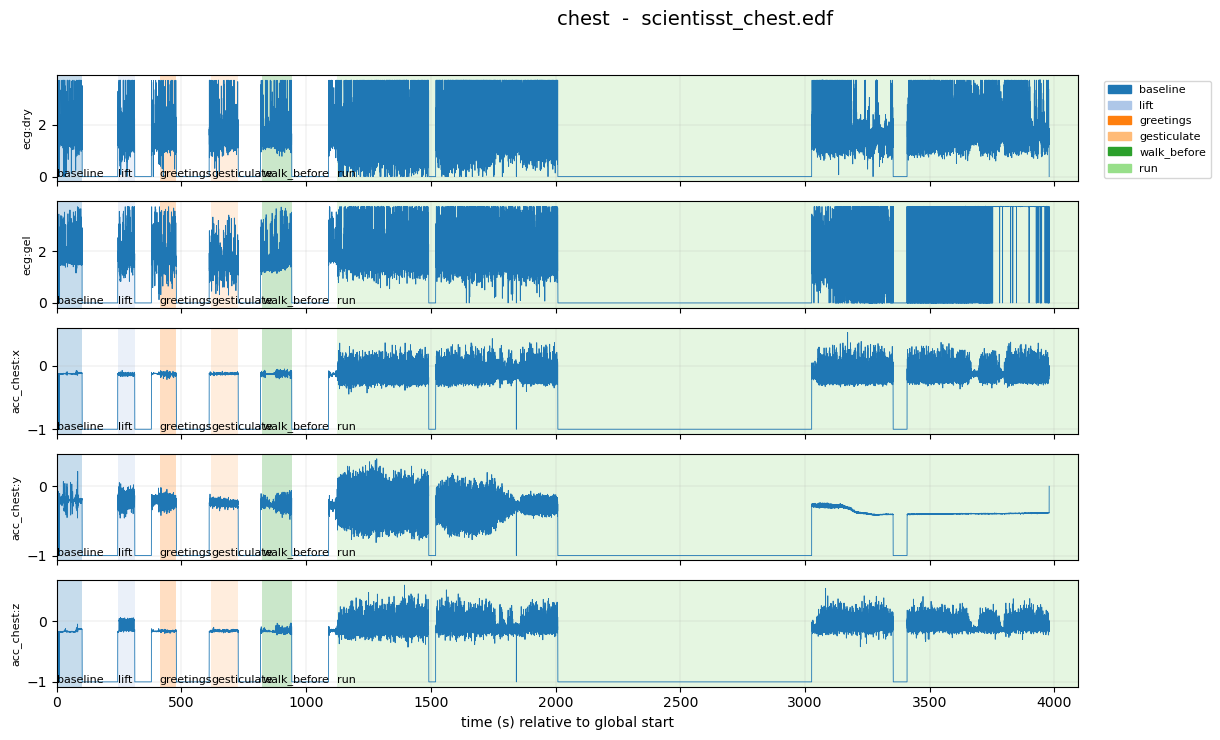

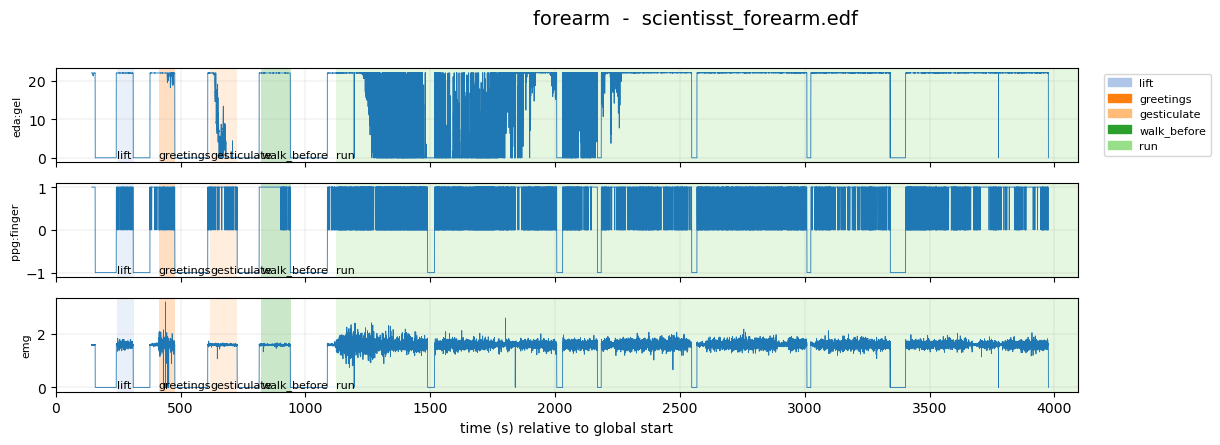

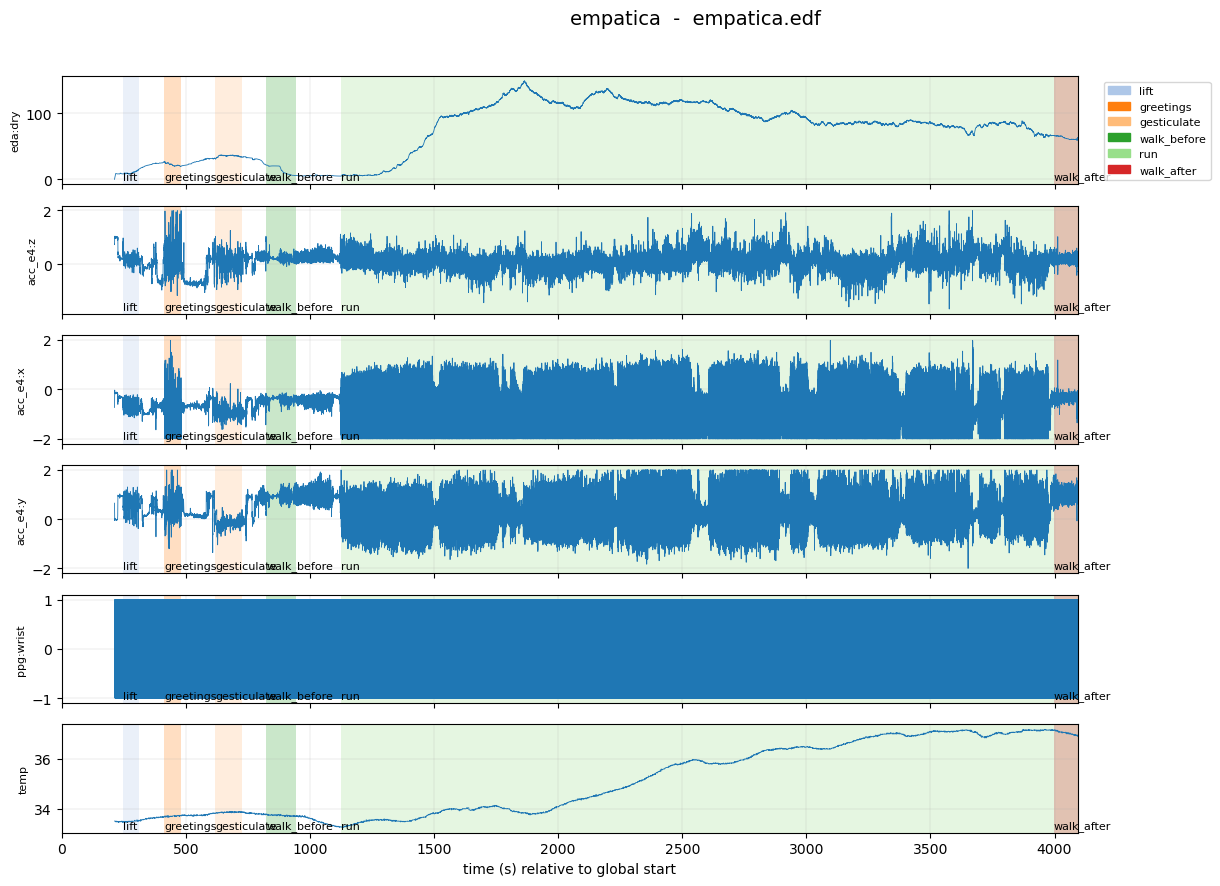

In [83]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import pyedflib
import os
from collections import OrderedDict

# ---------- 配置 ----------
# 如果你已经在交互环境中创建了 f1,f2,f3 (pyedflib.EdfReader instances)，
# 将 use_readers=True。否则把 use_readers=False 并设置 data_root 和 subj。
use_readers = True

# If not using existing readers, set data_root and subject id, then use_readers=False:
# data_root = "/path/to/data_root"   # 修改为你的路径
subject = "LK27"

# 如果 use_readers=False, 下面三行会被用到
path_chest = os.path.join(data_root, subject, 'scientisst_chest.edf')
path_fore = os.path.join(data_root, subject, 'scientisst_forearm.edf')
path_emp = os.path.join(data_root, subject, 'empatica.edf')

# 每个信号画图时最大显示点数（超过会下采样）：
MAX_POINTS_TO_PLOT = 50000

# 注释矩形透明度和文本大小
ANNOT_ALPHA = 0.25
ANNOT_TEXT_SIZE = 8

# ---------- 辅助函数 ----------
def reader_start_epoch(reader):
    """安全读取 start datetime -> epoch seconds，若无返回 0.0"""
    try:
        dt = reader.getStartdatetime()
        if dt is None:
            return 0.0
        return float(dt.timestamp())
    except Exception:
        # fallback: try header 'startdate' (pyedflib sometimes stores differently), else 0
        try:
            return float(reader.getFileOriginDate())  # may not exist
        except Exception:
            return 0.0

def extract_annotations(reader):
    """
    返回 list of (abs_onset_epoch, abs_end_epoch, label_str)
    """
    try:
        anns = reader.readAnnotations()
        onsets = anns[0]
        durations = anns[1]
        texts = anns[2]
        # decode bytes if necessary
        texts = [t.decode('utf-8') if isinstance(t, (bytes, bytearray)) else str(t) for t in texts]
    except Exception:
        return []
    start_epoch = reader_start_epoch(reader)
    out = []
    for o, d, t in zip(onsets, durations, texts):
        abs_o = start_epoch + float(o)
        abs_end = abs_o + float(d if d is not None else 0.0)
        out.append((abs_o, abs_end, t))
    return out

def get_label_color_map(labels):
    """为标签分配颜色（稳定但足够多）"""
    # 预选一组颜色（matplotlib tab20 +扩展）
    base = list(mcolors.TABLEAU_COLORS.keys()) + list(mcolors.CSS4_COLORS.keys())
    cmap = plt.get_cmap('tab20')
    color_list = [cmap(i) for i in range(cmap.N)]
    # 创建顺序映射
    uniq = list(OrderedDict.fromkeys(labels))
    cmap_map = {}
    for i, lab in enumerate(uniq):
        cmap_map[lab] = color_list[i % len(color_list)]
    return cmap_map

def downsample_for_plot(x, t, max_points):
    """如果点数太多则等间隔采样，返回 (x_ds, t_ds)"""
    n = len(x)
    if n <= max_points:
        return x, t
    step = max(1, int(np.ceil(n / max_points)))
    return x[::step], t[::step]


# ---------- 读取 / 准备 readers ----------
if use_readers:
    # 假定 f1,f2,f3 在当前命名空间（你之前定义的）
    try:
        f_chest = f1
        f_fore = f2
        f_emp = f3
    except NameError:
        raise RuntimeError("use_readers=True, 但未发现变量 f1/f2/f3。请先创建它们或设 use_readers=False 并提供路径。")
else:
    f_chest = pyedflib.EdfReader(path_chest)
    f_fore = pyedflib.EdfReader(path_fore)
    f_emp = pyedflib.EdfReader(path_emp)

devices = [
    ('chest', f_chest),
    ('forearm', f_fore),
    ('empatica', f_emp)
]

# ---------- 收集所有标签（用于配色） ----------
all_ann_labels = []
device_annotations = {}
for name, reader in devices:
    anns = extract_annotations(reader)
    device_annotations[name] = anns
    for (_, _, lab) in anns:
        all_ann_labels.append(lab)
if not all_ann_labels:
    print("[info] 没有在 EDF 注释中发现标签。图上将不会显示注释。")

label_to_color = get_label_color_map(all_ann_labels)

# ---------- 计算全局时间范围（以 epoch 为单位） ----------
start_epochs = []
end_epochs = []
for name, reader in devices:
    s = reader_start_epoch(reader)
    dur = float(reader.getFileDuration())
    start_epochs.append(s)
    end_epochs.append(s + dur)
global_start = min(start_epochs)
global_end = max(end_epochs)
global_span = global_end - global_start
print(f"Global time span: start={global_start}  end={global_end}  duration={global_span:.1f}s")

# ---------- 绘图：按设备分 Figure，每个通道一个 subplot ----------
for dev_idx, (dev_name, reader) in enumerate(devices):
    n_signals = reader.signals_in_file
    labels = reader.getSignalLabels()
    start_epoch = reader_start_epoch(reader)
    anns = device_annotations.get(dev_name, [])

    fig_h = max(3, n_signals * 1.5)
    fig, axes = plt.subplots(n_signals, 1, figsize=(14, fig_h), sharex=True)
    if n_signals == 1:
        axes = [axes]

    fig.suptitle(f"{dev_name}  -  {os.path.basename(reader.file_name)}", fontsize=14)

    for i in range(n_signals):
        ax = axes[i]
        try:
            sig = reader.readSignal(i).astype(np.float64)
        except Exception as e:
            print(f"[warn] 无法读取 {dev_name} 通道 {i}: {e}")
            continue
        fs = reader.getSampleFrequency(i)
        # 时间向量（秒），相对于 global_start（这样不同设备对齐）
        t = start_epoch + np.arange(len(sig)) / float(fs)
        t_rel = t - global_start  # 以 global_start 为零点更直观

        # 下采样以便绘图
        sig_ds, t_ds = downsample_for_plot(sig, t_rel, MAX_POINTS_TO_PLOT)

        ax.plot(t_ds, sig_ds, linewidth=0.6)
        ax.set_ylabel(labels[i], fontsize=8)
        ax.grid(True, linewidth=0.3, alpha=0.6)
        # 标注设备内注释（用绝对时间 -> 转成相对于 global_start）
        for (a0, a1, lab) in anns:
            # 如果注释和此通道时间无交集，可继续（绘制在全轨道上还是绘制在每个通道上，按你的需求）
            # 画矩形：x= (a0-global_start) ... (a1-global_start)
            x0 = a0 - global_start
            x1 = a1 - global_start
            # 若注释完全在绘图范围之外，跳过
            if x1 <= (t_rel[0]) or x0 >= (t_rel[-1]):
                continue
            color = label_to_color.get(lab, (0.8, 0.8, 0.8))
            width = x1 - x0
            rect = patches.Rectangle((x0, ax.get_ylim()[0]), width, ax.get_ylim()[1] - ax.get_ylim()[0],
                                     facecolor=color, alpha=ANNOT_ALPHA, edgecolor=None, linewidth=0)
            ax.add_patch(rect)
            # 在矩形中间放标签文本（限制文本不要溢出）
            tx = x0 + min(width * 0.02, 0.1)  # slight inset
            ty = ax.get_ylim()[0] + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.02
            ax.text(tx, ty, str(lab), fontsize=ANNOT_TEXT_SIZE, verticalalignment='bottom', bbox=dict(facecolor='white', alpha=0.0, edgecolor='none'))

    # x 轴标签放在最后一个子图
    axes[-1].set_xlabel("time (s) relative to global start")
    # 统一 x 轴范围
    for ax in axes:
        ax.set_xlim(0.0, global_end - global_start)

    # 图例：用自定义补丁显示标签颜色（只取该设备出现的标签）
    device_labels = list(OrderedDict.fromkeys([lab for (_, _, lab) in anns]))
    if device_labels:
        legend_patches = [patches.Patch(color=label_to_color[l], label=str(l)) for l in device_labels]
        axes[0].legend(handles=legend_patches, bbox_to_anchor=(1.02, 1.0), loc='upper left', fontsize=8)

    plt.tight_layout(rect=[0, 0, 0.88, 0.96])  # leave room for legend
    plt.show()

if not use_readers:
    f_chest.close()
    f_fore.close()
    f_emp.close()


### plot preprocessed signals

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# 定义通道名称映射（与数据集中的通道顺序对应）
CHANNEL_NAMES = [
    'ecg_chest_gel',           # 0
    'ecg_chest_textile',       # 1  
    'eda_forearm_scientisst',  # 2
    'eda_wrist_e4',           # 3
    'ppg_forearm_scientisst',  # 4
    'ppg_wrist_e4',           # 5
    'emg_forearm',            # 6
    'temp_wrist',             # 7
    'c_acc_x',                # 8
    'c_acc_y',                # 9
    'c_acc_z',                # 10
    'w_acc_x',                # 11
    'w_acc_y',                # 12
    'w_acc_z',                # 13
]

def plot_subject_windows_integrated(dataset, subject_id='LK27'):
    """
    绘制集成tensor版本的subject数据
    dataset: 修改后的MoveEDFWindowDataset
    """
    # 收集该subject的所有window数据
    subject_windows = []
    for w in dataset.processed_windows:
        if w.subject_id == subject_id:
            # w.x_tensor shape: [C=14, T=100]
            subject_windows.append(w.x_tensor.numpy())
    
    if not subject_windows:
        print(f"No windows found for subject {subject_id}")
        return
    
    # 拼接所有windows: (num_windows, 14, 100) -> (14, num_windows*100)
    concat_data = np.concatenate(subject_windows, axis=-1)  # [14, total_time]
    print(f"Found {len(subject_windows)} windows for subject {subject_id}")
    print(f"Concatenated data shape: {concat_data.shape}")
    
    # 为每组相关信号创建子图
    signal_groups = {
        'ECG Signals': [0, 1],  # ecg_chest_gel, ecg_chest_textile
        'EDA Signals': [2, 3],  # eda_forearm_scientisst, eda_wrist_e4  
        'PPG Signals': [4, 5],  # ppg_forearm_scientisst, ppg_wrist_e4
        'EMG & Temperature': [6, 7],  # emg_forearm, temp_wrist
        'Chest Accelerometer': [8, 9, 10],  # c_acc_x, c_acc_y, c_acc_z
        'Wrist Accelerometer': [11, 12, 13],  # w_acc_x, w_acc_y, w_acc_z
    }
    
    fig, axes = plt.subplots(len(signal_groups), 1, figsize=(20, 15))
    fig.suptitle(f'Subject {subject_id} - All Signal Types', fontsize=16)
    
    for i, (group_name, channel_indices) in enumerate(signal_groups.items()):
        ax = axes[i]
        
        for ch_idx in channel_indices:
            if ch_idx < concat_data.shape[0]:
                ax.plot(concat_data[ch_idx], label=CHANNEL_NAMES[ch_idx], alpha=0.8)
        
        ax.set_title(group_name)
        ax.set_xlabel('Time (samples)')
        ax.set_ylabel('Amplitude')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_subject_windows_by_channel(dataset, subject_id='LK27'):
    """
    按通道类型分别绘制（每个信号类型单独一个图）
    """
    # 收集该subject的所有window数据
    subject_windows = []
    for w in dataset.processed_windows:
        if w.subject_id == subject_id:
            subject_windows.append(w.x_tensor.numpy())
    
    if not subject_windows:
        print(f"No windows found for subject {subject_id}")
        return
    
    # 拼接所有windows
    concat_data = np.concatenate(subject_windows, axis=-1)  # [14, total_time]
    
    # 为每个信号类型创建单独的图
    signal_groups = {
        'ECG Signals': [0, 1],
        'EDA Signals': [2, 3], 
        'PPG Signals': [4, 5],
        'EMG & Temperature': [6, 7],
        'Chest Accelerometer': [8, 9, 10],
        'Wrist Accelerometer': [11, 12, 13],
    }
    
    for group_name, channel_indices in signal_groups.items():
        plt.figure(figsize=(20, 6))
        
        for ch_idx in channel_indices:
            if ch_idx < concat_data.shape[0]:
                plt.plot(concat_data[ch_idx], label=CHANNEL_NAMES[ch_idx], alpha=0.8)
        
        plt.title(f'{subject_id} - {group_name}')
        plt.xlabel('Time (samples)')
        plt.ylabel('Amplitude')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

def plot_single_window(dataset, subject_id='LK27', window_idx=0):
    """
    绘制单个window的所有通道数据
    """
    # 找到指定subject的windows
    subject_window_indices = dataset.subject_to_windows.get(subject_id, [])
    
    if not subject_window_indices or window_idx >= len(subject_window_indices):
        print(f"Window {window_idx} not found for subject {subject_id}")
        return
    
    # 获取指定window的数据
    global_window_idx = subject_window_indices[window_idx]
    window = dataset.processed_windows[global_window_idx]
    
    # window.x_tensor shape: [14, 100]
    data = window.x_tensor.numpy()
    
    # 创建子图
    fig, axes = plt.subplots(7, 2, figsize=(15, 20))
    fig.suptitle(f'Subject {subject_id} - Window {window_idx} (Label: {window.y})', fontsize=16)
    
    axes = axes.flatten()
    
    for i in range(min(14, len(axes))):
        axes[i].plot(data[i])
        axes[i].set_title(CHANNEL_NAMES[i])
        axes[i].set_xlabel('Time (samples)')
        axes[i].set_ylabel('Amplitude')
        axes[i].grid(True, alpha=0.3)
    
    # 隐藏多余的子图
    for i in range(14, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()

def plot_label_distribution(dataset):
    """
    绘制标签分布
    """
    label_counts = defaultdict(int)
    
    for window in dataset.processed_windows:
        if window.y is not None:
            # 从label_map中找到对应的标签名
            label_name = None
            for name, idx in dataset.label_map.items():
                if idx == window.y:
                    label_name = name
                    break
            if label_name:
                label_counts[label_name] += 1
    
    labels = list(label_counts.keys())
    counts = list(label_counts.values())
    
    plt.figure(figsize=(12, 6))
    bars = plt.bar(labels, counts)
    plt.title('Label Distribution')
    plt.xlabel('Labels')
    plt.ylabel('Number of Windows')
    plt.xticks(rotation=45, ha='right')
    
    # 在柱子上显示数值
    for bar, count in zip(bars, counts):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*max(counts), 
                str(count), ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    print("Label distribution:")
    for label, count in sorted(label_counts.items()):
        print(f"  {label}: {count}")


Found 371 windows for subject LK27
Concatenated data shape: (14, 37100)


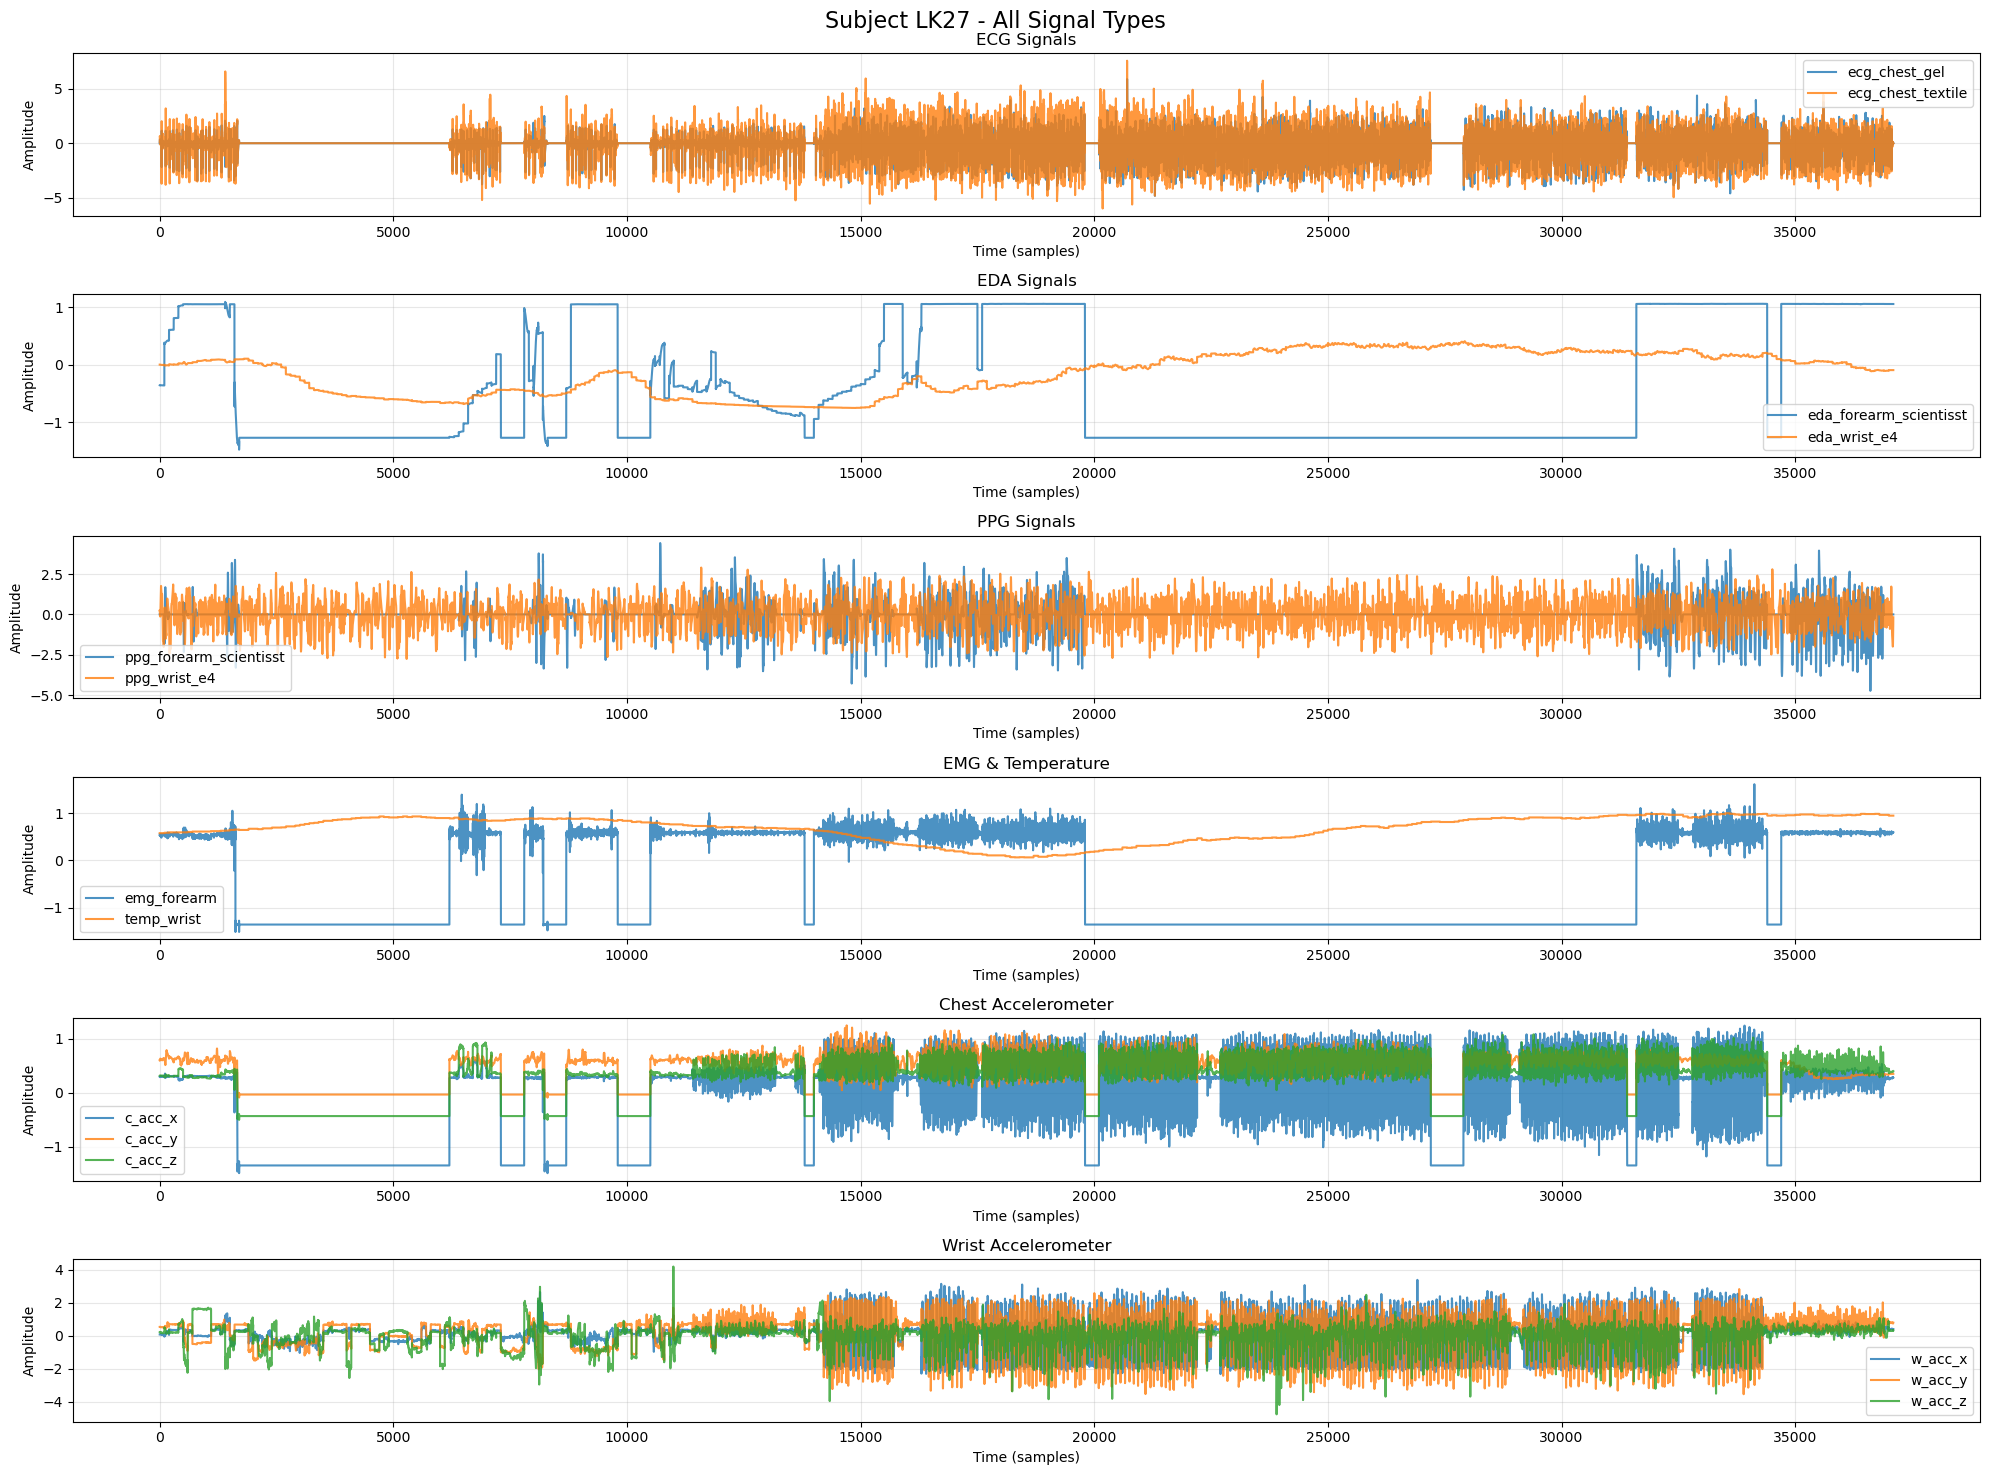

In [22]:
plot_subject_windows_integrated(dataset, 'LK27') # LK27 4JF9

# mHEALTH Dataset

In [85]:
import os
import numpy as np
import pandas as pd
import logging
from scipy import stats
from torch.utils.data import Dataset, DataLoader
from torch.distributed import get_rank, is_initialized
import torch
from sklearn.utils import resample
from collections import Counter

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


def log_info(msg):
    if not is_initialized() or get_rank() == 0:
        logger.info(msg)


class MHealthDataset(Dataset):
    def __init__(self, data_root, subjects, time_steps=100, step=50, balance=False, majority_n=30000, remove_zero_activity=True):
        """
        Args:
            data_root: Data directory path
            subjects: List of subjects to load (e.g. [1,2,3])
            time_steps: Sliding window length
            step: Sliding window step size
            balance: Whether to downsample Activity=0 samples (or the majority class)
            majority_n: Number of samples after downsampling
            remove_zero_activity: Whether to remove Activity=0 samples. If True, labels start from 0; if False, labels include 0
        """
        self.remove_zero_activity = remove_zero_activity
        self.X, self.y = self._load_and_window(data_root, subjects, time_steps, step, balance, majority_n)

    def _load_and_window(self, data_root, subjects, time_steps, step, balance, majority_n):
        all_Xs, all_ys = [], []

        # Process each subject separately
        for subject_id in subjects:
            path = os.path.join(data_root, f"mHealth_subject{subject_id}.log")
            df = pd.read_csv(path, header=None, sep="\t")

            # Select feature columns
            df = df.loc[:, [5, 6, 7, 8, 9, 10, 14, 15, 16, 17, 18, 19, 23]]
            df = df.rename(columns={
                5: "alx", 6: "aly", 7: "alz",
                8: "glx", 9: "gly", 10: "glz",
                14: "arx", 15: "ary", 16: "arz",
                17: "grx", 18: "gry", 19: "grz",
                23: "Activity"
            })

            # Remove missing values
            df = df.dropna()
            
            # Handle Activity=0 based on parameter
            if self.remove_zero_activity:
                df = df[df['Activity'] > 0]  # Remove Activity=0
                # Relabel activities to start from 0
                unique_activities = sorted(df['Activity'].unique())
                activity_mapping = {old_label: new_label for new_label, old_label in enumerate(unique_activities)}
                df['Activity'] = df['Activity'].map(activity_mapping)
                if subject_id == 0:
                    log_info(f"Subject {subject_id}: Activity mapping after removing zero activity: {activity_mapping}")
            else:
                if subject_id == 0:
                # Keep Activity=0, no relabeling needed
                    log_info(f"Subject {subject_id}: Keeping Activity=0, original labels preserved")

            # Apply sliding window to current subject
            X = df.drop(['Activity'], axis=1)
            y = df['Activity']

            subject_Xs, subject_ys = [], []
            for i in range(0, len(X) - time_steps + 1, step):
                x_window = X.iloc[i:(i + time_steps)].values
                y_window = y.iloc[i:(i + time_steps)]

                # Check label consistency within the window
                unique_labels = y_window.unique()
                if len(unique_labels) == 1:
                    # Only one activity label in the window, use it directly
                    label = unique_labels[0]
                else:
                    # Multiple activity labels in the window, use majority vote or skip
                    label_counts = Counter(y_window)
                    most_common = label_counts.most_common(1)[0]

                    # Skip window if majority vote ratio is too low
                    if most_common[1] / len(y_window) < 0.8:
                        continue
                    label = most_common[0]

                subject_Xs.append(x_window)
                subject_ys.append(label)

            all_Xs.extend(subject_Xs)
            all_ys.extend(subject_ys)

        # Convert to numpy arrays
        Xs = np.array(all_Xs, dtype=np.float32)
        ys = np.array(all_ys, dtype=np.int64)

        # Balance at window level
        if balance:
            # Count samples for each class
            unique_labels, counts = np.unique(ys, return_counts=True)
            log_info(f"Sample distribution before balancing: {dict(zip(unique_labels, counts))}")

            # Find the class that needs downsampling (usually the one with most samples)
            max_count_idx = np.argmax(counts)
            majority_class = unique_labels[max_count_idx]

            # Separate majority and minority classes
            majority_mask = (ys == majority_class)
            minority_mask = ~majority_mask

            Xs_majority = Xs[majority_mask]
            ys_majority = ys[majority_mask]
            Xs_minority = Xs[minority_mask]
            ys_minority = ys[minority_mask]

            # Downsample majority class
            if len(Xs_majority) > majority_n:
                np.random.seed(42)
                downsample_indices = np.random.choice(
                    len(Xs_majority),
                    size=majority_n,
                    replace=False
                )
                Xs_majority = Xs_majority[downsample_indices]
                ys_majority = ys_majority[downsample_indices]

            # Recombine data
            Xs = np.concatenate([Xs_majority, Xs_minority], axis=0)
            ys = np.concatenate([ys_majority, ys_minority], axis=0)

            # Shuffle data order
            shuffle_indices = np.random.permutation(len(Xs))
            Xs = Xs[shuffle_indices]
            ys = ys[shuffle_indices]

        # Print final class distribution
        unique_labels, counts = np.unique(ys, return_counts=True)
        log_info(f"Final sample distribution: {dict(zip(unique_labels, counts))}")
        log_info(f"Total number of windows: {len(Xs)}")
        log_info(f"Feature shape: {Xs.shape}")

        return Xs, ys

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx])
        x = x.transpose(0, 1)  # Transpose to (features, time_steps)
        y = torch.tensor(self.y[idx], dtype=torch.long)
        return x, y


def get_dataloaders(data_root, batch_size=64, time_steps=100, step=50, balance=False, remove_zero_activity=True):
    """
    Create train and test data loaders
    
    Args:
        data_root: Data directory path
        batch_size: Batch size for data loaders
        time_steps: Sliding window length
        step: Sliding window step size
        balance: Whether to balance the dataset
        remove_zero_activity: Whether to remove Activity=0 samples
    
    Returns:
        train_loader, test_loader: PyTorch DataLoader objects
    """
    train_subjects = [i for i in range(1, 9)]  # Subjects 1-8 for training
    test_subjects = [9, 10]  # Subjects 9-10 for testing

    train_dataset = MHealthDataset(
        data_root,
        train_subjects,
        time_steps,
        step,
        balance=balance,
        remove_zero_activity=remove_zero_activity
    )
    test_dataset = MHealthDataset(
        data_root,
        test_subjects,
        time_steps,
        step,
        balance=False,  # Usually don't balance test set
        remove_zero_activity=remove_zero_activity
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader

In [33]:
batch_size=64
time_steps=100
step=50
train_subjects = [i for i in range(1, 9)]  # subject1-8
test_subjects  = [9, 10]

train_dataset = MHealthDataset('/Users/chengweizhou/PycharmProjects/data/MHEALTHDATASET', train_subjects, time_steps, step, balance=True, majority_n=482)
val_dataset = MHealthDataset('/Users/chengweizhou/PycharmProjects/data/MHEALTHDATASET', test_subjects, time_steps, step, balance=False, majority_n=6144)

INFO:__main__:Sample distribution before balancing: {np.int64(0): np.int64(480), np.int64(1): np.int64(480), np.int64(2): np.int64(483), np.int64(3): np.int64(485), np.int64(4): np.int64(479), np.int64(5): np.int64(452), np.int64(6): np.int64(468), np.int64(7): np.int64(461), np.int64(8): np.int64(483), np.int64(9): np.int64(483), np.int64(10): np.int64(482), np.int64(11): np.int64(154)}
INFO:__main__:Final sample distribution: {np.int64(0): np.int64(480), np.int64(1): np.int64(480), np.int64(2): np.int64(483), np.int64(3): np.int64(482), np.int64(4): np.int64(479), np.int64(5): np.int64(452), np.int64(6): np.int64(468), np.int64(7): np.int64(461), np.int64(8): np.int64(483), np.int64(9): np.int64(483), np.int64(10): np.int64(482), np.int64(11): np.int64(154)}
INFO:__main__:Total number of windows: 5387
INFO:__main__:Feature shape: (5387, 100, 12)
INFO:__main__:Final sample distribution: {np.int64(0): np.int64(120), np.int64(1): np.int64(120), np.int64(2): np.int64(121), np.int64(3): n

In [37]:
print(len(train_dataset))
print(len(val_dataset))
print(train_dataset[0][0].shape)
# print(train_dataset.df.Activity.keys())

5387
1332
torch.Size([12, 100])


In [88]:
print(len(train_dataset[0]), train_dataset[0])
train_dataset[0][0].shape

2 (tensor([[ 2.1849, -9.6967,  0.6308,  ..., -0.4490, -1.0103,  0.0345],
        [ 2.3876, -9.5080,  0.6839,  ..., -0.4490, -1.0103,  0.0345],
        [ 2.4086, -9.5674,  0.6811,  ..., -0.4490, -1.0103,  0.0345],
        ...,
        [ 1.5577, -9.7415,  0.1118,  ..., -0.5078, -0.9980,  0.0129],
        [ 1.2922, -9.6916,  0.1429,  ..., -0.5078, -0.9980,  0.0129],
        [ 1.4417, -9.6452, -0.1658,  ..., -0.5078, -0.9980,  0.0129]]), tensor(0))


torch.Size([100, 12])